# Kapitel 3: Attention Mechanisms Implementieren

- Benötigte Pakete:

In [1]:
from importlib.metadata import version

print("torch version:", version("torch"))

torch version: 2.11.0


## Warum brauchen wir Attention Mechanismen?

- Das Problem mit langen Sequenzen


- Vor Transformern wurden Encoder-Decoder-RNNs für Aufgaben wie maschinelle Übersetzung 
verwendet. Der Encoder verarbeitet die Eingabe Token für Token und aktualisiert dabei 
einen Hidden State (Ein Vektor, er nach jedem Token aktualisiert wird und die bisherige Sequenz komprimiert zusammenfassen soll).

- Das Problem:  Jeder neue Token überschreibt den vorherigen Hidden State teilweise.
Am Ende der Sequenz enthält der finale Vektor vor allem Information über die 
letzten Tokens und kaum noch Informationen über die ersten Tokens durch die wiederholte Transformation.


- Attention löst das Problem, indem der Decoder nicht nur auf den finalen Hidden State 
  zugreift, sondern auf alle Hidden States zu jedem Zeitpunkt der Sequenz selektiv zugreifen kann. So kann gezielt gewichtet werden, welche Tokens für den aktuellen Ausgabe-Schritt relevant sind.


## Siplifizierter Self-Attention Mechanismus

- Self-Attention geht über klassische Attention hinaus: Jede Position einer Sequenz bestimmt die Relevanz zu 
jeder anderen Position in derselben Sequenz. So wird jedes Token durch den Kontext 
aller anderen Tokens angereichert.


- Im folgenden wird ein beispielhaft ein simplifizierter Self-Attention Mechanismus beschrieben (ohne trainierbare Gewichte)

#### Beispiel: 
- Aus einem Input Text wurde wie in Kapitel 2 beschrieben bereits tokenisierte Embeddings erstellt
- Daraus ergibt sich eine Input Sequenz $x^{(1)}$ to $x^{(T)}$. Jedes $x^{(i)}$ steht für ein Token-Embedding

#### Ziel:
- Für jedes Token Embedding $x^{(i)}$ soll ein Kontextvektor $z^{(i)}$ erstellt werden.
    - $z^{(i)}$ ist eine gewichtete Summe aller Input-Tokens $z^{(1)}$ bis $z^{(T)}$
    - Die Gewichte (Attention Weights) sind token-spezifisch: Wenn wir $z^{(2)}$ berechnen, bekommt jedes Token ein Gewicht das angibt, wie relevant es für $x^{(2)}$ ist. Für $z^{(3)}$ werden dieselben Inputs neu gewichtet, dann aus der Perspektive von $x^{(3)}$.
    -  $z^{(2)}$ ist also eine angereicherte Version von $x^{(2)}$, die den relevanten Kontext der gesamten Sequenz in sich trägt


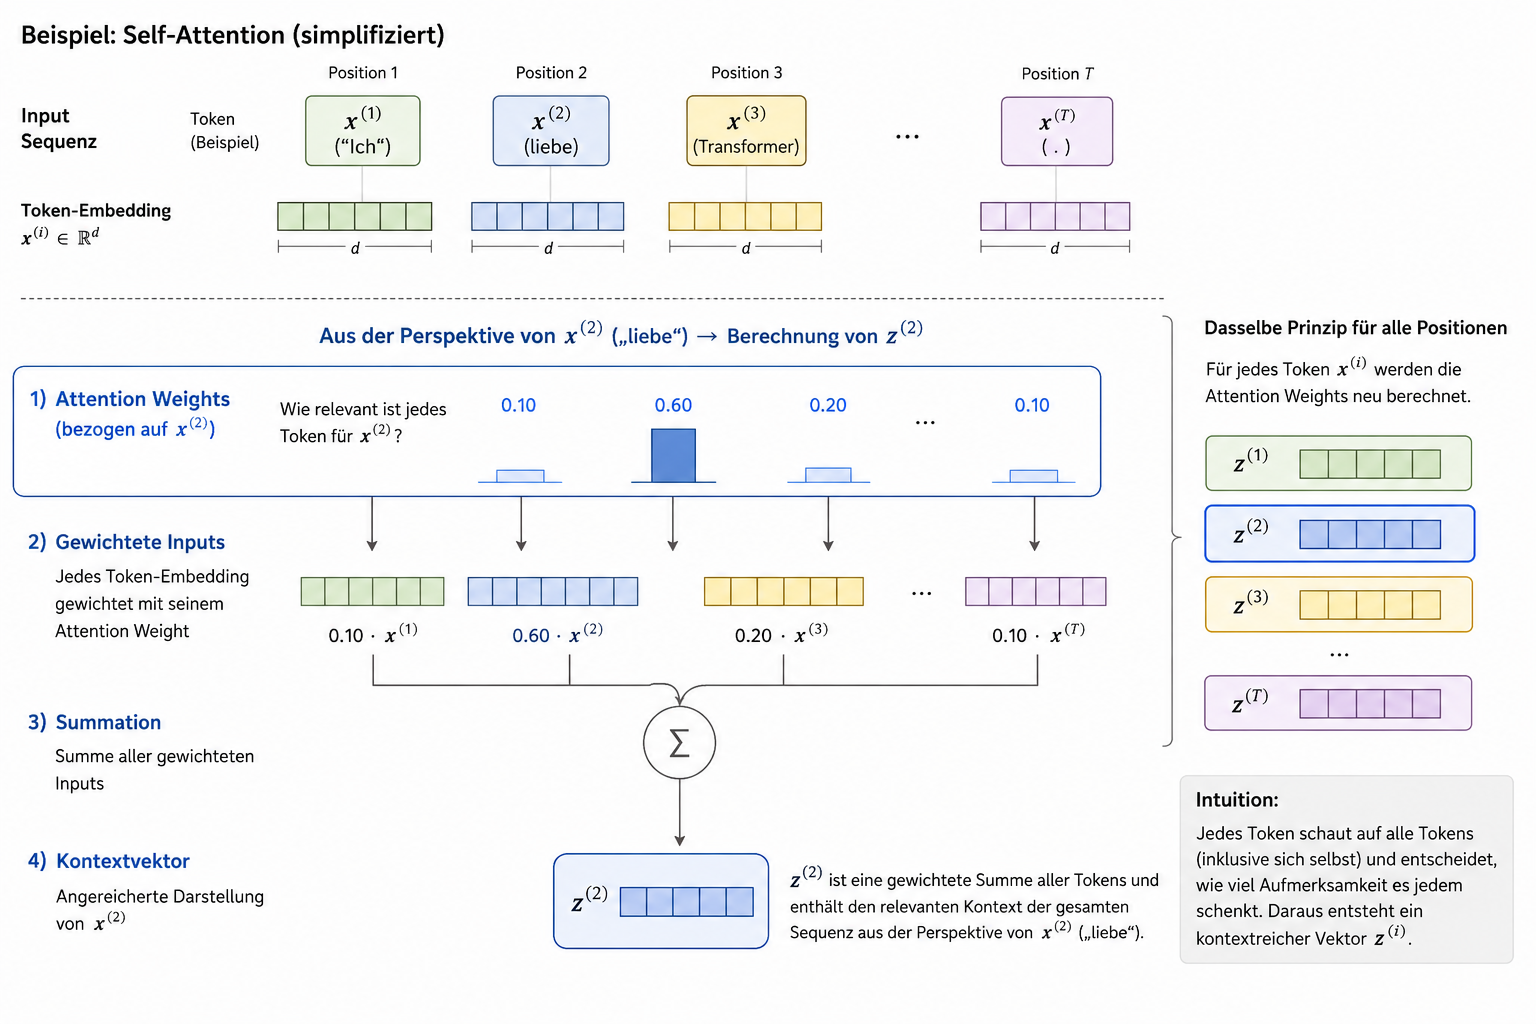

Quelle: OpenAI Images 2 

Input: Die Markdown Blöcke über dem Bild + " Erstelle mir aus diesem Beispiel eine Illustration"

#### Code Beispiel:
- Gegeben sind drei tokenisierte Embeddings ($x^{(1)}$, $x^{(2)}$, $x^{(3)}$), des Satzes "Ich liebe Transformer" 

In [ ]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Ich         = (x^1)
   [0.55, 0.87, 0.66], # liebe       = (x^2)
   [0.57, 0.85, 0.64]] # Transformer = (x^3)
)

- Ziel des Beispiels ist es den Kontextverktor $z^{(3)}$ für $x^{(3)}$ ("Transformer") zu berechnen bevor später für jedes $x^{(i)}$ ein Kontextvektor $z^{(i)}$ berechnet wird

#### Schritt 1: Berechnung der Attention Scores
- Aus dem Skalarprodukt von $x^{(3)}$ mit sich selbst und den anderen Embeddings $x^{(1)}$, $x^{(2)}$ werden unnormalisierte Gewichte (Attention Scores) berechnet
- Die Attention Scores geben an, wie relevant jedes Token $x^{(i)}$ für das Query-Token x^(3) ist.